# 03 — Analyse

Ce notebook teste l'hypothèse formulée à partir du dataset nettoyé produit par `02_data_cleaning.ipynb`. L'approche privilégie des statistiques simples (pourcentages, intervalles de confiance) directement interprétables, complétées par des visualisations et des tests de robustesse.


## Hypothèse testée

Le mode de réalisation d'un programme de logement social détermine sa composition en types de financement. En particulier, l'acquisition-conventionnement (rachat de logements existants) produit une proportion de logements très sociaux (PLA I) nettement plus faible que la construction neuve ou l'acquisition-réhabilitation, au profit des logements PLS (intermédiaires).

## Méthode

- Analyse principale restreinte à `nature_programme == "logement familial"` (le facteur de confusion `nature_programme` a été identifié dans `01_data_understanding.ipynb`)
- Calcul du pourcentage de logements PLA I par mode de réalisation, avec intervalle de confiance à 95%
- Visualisations à chaque étape clé
- Vérifications de robustesse : dataset complet (sans filtre), par arrondissement, par période


## 1. Chargement des données nettoyées


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportion_confint

df = pd.read_csv("../data/processed/logements-sociaux-paris-clean.csv", sep=';')
print("Shape :", df.shape)
df.head()


Shape : (4172, 17)


,id_livraison,adresse_programme,code_postal,annee,bs,nb_logmt_total,nb_plai,nb_plus,nb_pluscd,nb_pls,mode_real,arrdt,nature_programme,coord_x_l93,coord_y_l93,geo_shape,geo_point_2d
0,2000011,16-20 RUE DES MEUNIERS,75012,2001,RES.URB.,62,0,62,0,0,acquisition conventionnement,12,logement familial,655823.1529,6.859495e+06,"{""coordinates"": [2.398175442412243, 48.8339981...","48.83399817959342, 2.398175442412243"
1,2000035,25 RUE DES ANNELETS,75019,2001,RIVP,18,10,8,0,0,acquisition réhabilitation,19,logement familial,655225.8330,6.864433e+06,"{""coordinates"": [2.3895183752327043, 48.878361...","48.8783619998301, 2.3895183752327043"
2,2000044,LOT D1B - 86 RUE DES HAIES,75020,2001,RIVP,6,0,6,0,0,acquisition réhabilitation,20,logement familial,656258.4385,6.861828e+06,"{""coordinates"": [2.403865260493333, 48.8550036...","48.85500366971155, 2.403865260493333"
3,2000048,31 QUAI DE VALMY,75010,2001,PARIS HABITAT,28,0,22,0,6,acquisition conventionnement,10,logement familial,653551.4260,6.863384e+06,"{""coordinates"": [2.366804047083707, 48.8688074...","48.86880747974437, 2.366804047083707"
4,2000062,19 RUE DES PLANTES,75014,2001,PARIS HABITAT,38,0,15,0,23,acquisition conventionnement,14,logement familial,650356.4410,6.859151e+06,"{""coordinates"": [2.3237456731730535, 48.830499...","48.83049983027532, 2.3237456731730535"


## 2. Filtre sur le logement familial

On restreint l'analyse principale à `nature_programme == "logement familial"` pour éviter que les résidences spécialisées (étudiantes, EHPAD, foyers...) ne biaisent la comparaison entre modes de réalisation (cf. `01_data_understanding.ipynb`, section conclusions).


In [32]:
df_familial = df[df['nature_programme'] == 'logement familial'].copy()
print(f"Logement familial : {len(df_familial)} programmes sur {len(df)} "
      f"({len(df_familial)/len(df)*100:.1f}%)")


Logement familial : 3550 programmes sur 4172 (85.1%)


### Visualisation — poids du logement familial dans le dataset


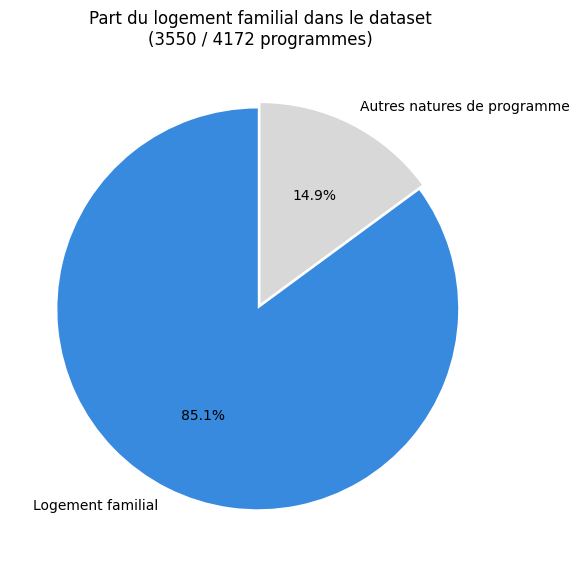

In [33]:
counts = [len(df_familial), len(df) - len(df_familial)]
labels = ['Logement familial', 'Autres natures de programme']
colors = ['#378ADD', '#D8D8D8']

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(counts, labels=labels, autopct='%1.1f%%', colors=colors,
       startangle=90, explode=(0.03, 0))
ax.set_title(f"Part du logement familial dans le dataset\n"
             f"({len(df_familial)} / {len(df)} programmes)")
plt.tight_layout()
plt.savefig("../outputs/pct_logement_familial.png", dpi=150)
plt.show()


## 3. Pourcentage de logements PLA I par mode de réalisation

Statistique simple : sur l'ensemble des logements produits par chaque mode de réalisation, quelle part est du PLA I (le financement le plus social) ?


In [34]:
totaux = df_familial.groupby('mode_real')[['nb_plai', 'nb_plus', 'nb_pluscd', 'nb_pls', 'nb_logmt_total']].sum()
totaux['pct_plai'] = (totaux['nb_plai'] / totaux['nb_logmt_total'] * 100).round(1)
totaux['pct_pls'] = (totaux['nb_pls'] / totaux['nb_logmt_total'] * 100).round(1)

print(totaux[['nb_logmt_total', 'nb_plai', 'pct_plai', 'nb_pls', 'pct_pls']])


                              nb_logmt_total  nb_plai  pct_plai  nb_pls  \
mode_real                                                                 
acquisition conventionnement           46278     7365      15.9   18597   
acquisition réhabilitation             16903     4417      26.1    4442   
construction neuve                     26094     4719      18.1    9966   

                              pct_pls  
mode_real                              
acquisition conventionnement     40.2  
acquisition réhabilitation       26.3  
construction neuve               38.2  


### Visualisation — répartition complète du financement par mode de réalisation

Le % de PLA I seul ne dit pas où va la différence. Ce graphique empilé montre la composition complète (PLAI/PLUS/PLUSCD/PLS) pour chaque mode — utile pour vérifier si le déficit de PLAI en acquisition-conventionnement est compensé par plus de PLS (logements intermédiaires), comme le suggère l'hypothèse.


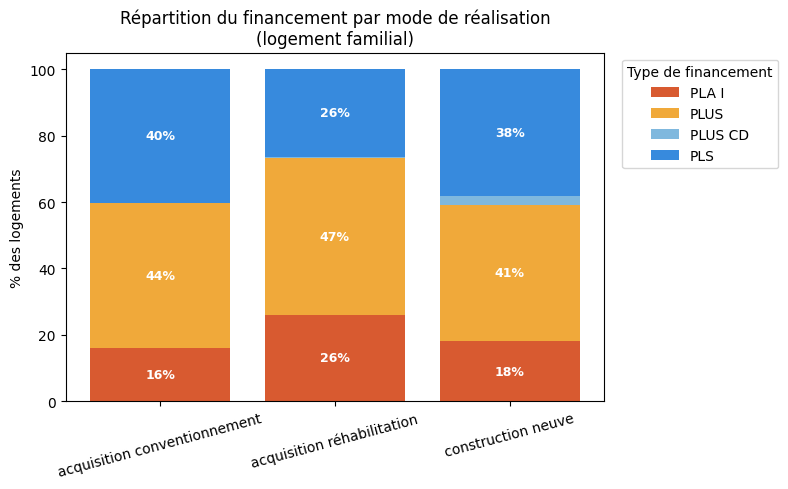

In [35]:
financements = ['nb_plai', 'nb_plus', 'nb_pluscd', 'nb_pls']
labels_fin = ['PLA I', 'PLUS', 'PLUS CD', 'PLS']
pct_stack = totaux[financements].div(totaux['nb_logmt_total'], axis=0) * 100

fig, ax = plt.subplots(figsize=(8, 5))
bottom = pd.Series(0.0, index=pct_stack.index)
colors = ['#D85A30', '#F0A93A', '#7FB8DE', '#378ADD']

for fin, lab, color in zip(financements, labels_fin, colors):
    ax.bar(pct_stack.index, pct_stack[fin], bottom=bottom, label=lab, color=color)
    for i, (idx, val) in enumerate(pct_stack[fin].items()):
        if val > 3:
            ax.text(i, bottom[idx] + val/2, f"{val:.0f}%", ha='center', va='center',
                    fontsize=9, color='white', fontweight='bold')
    bottom += pct_stack[fin]

ax.set_ylabel("% des logements")
ax.set_title("Répartition du financement par mode de réalisation\n(logement familial)")
ax.legend(title="Type de financement", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/repartition_financement_par_mode.png", dpi=150)
plt.show()


## 4. Intervalle de confiance sur le pourcentage de PLA I

On ajoute une marge d'incertitude à chaque pourcentage : avec 95% de certitude, le vrai pourcentage de PLA I se situe dans cet intervalle. Si les intervalles de deux modes ne se chevauchent pas, la différence observée n'est pas due au hasard.


In [36]:
print("Pourcentage de logements PLA I par mode de réalisation (avec IC à 95%) :\n")

resultats = {}
for mode in df_familial['mode_real'].unique():
    sub = df_familial[df_familial['mode_real'] == mode]
    plai = sub['nb_plai'].sum()
    total = sub['nb_logmt_total'].sum()
    pct = plai / total * 100
    low, high = proportion_confint(plai, total, alpha=0.05, method='wilson')
    resultats[mode] = {'pct': pct, 'low': low * 100, 'high': high * 100, 'n': total}
    print(f"{mode:32s} {pct:5.1f}%   (IC95% : {low*100:.1f}% - {high*100:.1f}%,  n={total} logements)")


Pourcentage de logements PLA I par mode de réalisation (avec IC à 95%) :

acquisition conventionnement      15.9%   (IC95% : 15.6% - 16.3%,  n=46278 logements)
acquisition réhabilitation        26.1%   (IC95% : 25.5% - 26.8%,  n=16903 logements)
construction neuve                18.1%   (IC95% : 17.6% - 18.6%,  n=26094 logements)


### Visualisation — comparaison avec intervalles de confiance


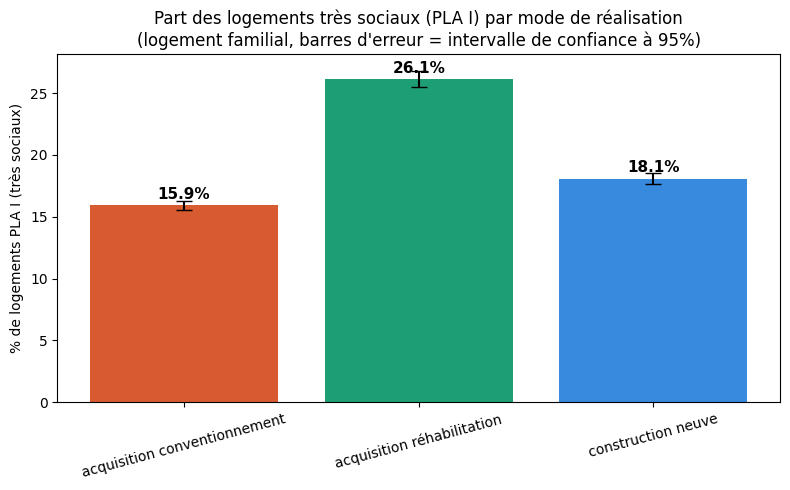

In [37]:
modes = list(resultats.keys())
pcts = [resultats[m]['pct'] for m in modes]
errs_low = [resultats[m]['pct'] - resultats[m]['low'] for m in modes]
errs_high = [resultats[m]['high'] - resultats[m]['pct'] for m in modes]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modes, pcts, yerr=[errs_low, errs_high], capsize=6,
              color=['#D85A30', '#1D9E75', '#378ADD'])

for bar, pct in zip(bars, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{pct:.1f}%", ha='center', fontsize=11, fontweight='bold')

ax.set_ylabel("% de logements PLA I (très sociaux)")
ax.set_title("Part des logements très sociaux (PLA I) par mode de réalisation\n"
              "(logement familial, barres d'erreur = intervalle de confiance à 95%)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../outputs/pct_plai_par_mode.png", dpi=150)
plt.show()


## 5. Ratio entre acquisition-conventionnement et les deux autres modes

Chiffre central de l'hypothèse : de combien de fois le taux de PLA I en acquisition-conventionnement est-il inférieur à celui des deux autres modes ?


In [38]:
pct_ac = resultats['acquisition conventionnement']['pct']
pct_ar = resultats['acquisition réhabilitation']['pct']
pct_cn = resultats['construction neuve']['pct']
pct_autres = (pct_ar + pct_cn) / 2

ratio = pct_autres / pct_ac

print(f"PLA I en acquisition-conventionnement     : {pct_ac:.1f}%")
print(f"PLA I en acquisition-réhabilitation        : {pct_ar:.1f}%")
print(f"PLA I en construction neuve                : {pct_cn:.1f}%")
print(f"Moyenne des deux autres modes               : {pct_autres:.1f}%")
print(f"\nRatio (autres modes / acquisition-conventionnement) : {ratio:.1f}x")


PLA I en acquisition-conventionnement     : 15.9%
PLA I en acquisition-réhabilitation        : 26.1%
PLA I en construction neuve                : 18.1%
Moyenne des deux autres modes               : 22.1%

Ratio (autres modes / acquisition-conventionnement) : 1.4x


### Visualisation — écart mis en évidence


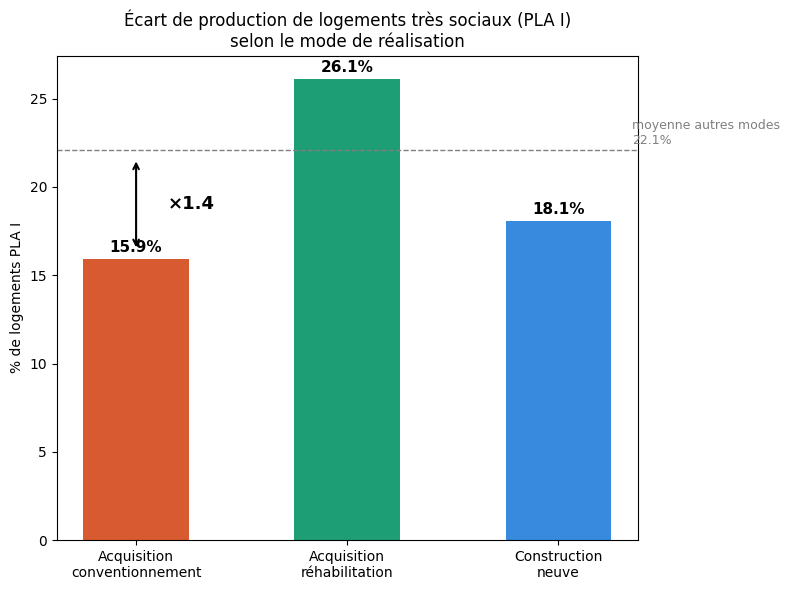

In [39]:
modes_lbl = ['Acquisition\nconventionnement', 'Acquisition\nréhabilitation', 'Construction\nneuve']
values = [pct_ac, pct_ar, pct_cn]
colors = ['#D85A30', '#1D9E75', '#378ADD']

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(modes_lbl, values, color=colors, width=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

ax.axhline(pct_autres, color='gray', linestyle='--', linewidth=1)
ax.text(2.35, pct_autres + 0.3, f"moyenne autres modes\n{pct_autres:.1f}%",
        fontsize=9, color='gray', ha='left')

ax.annotate('', xy=(0, pct_ac + 0.5), xytext=(0, pct_autres - 0.5),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text(0.15, (pct_ac + pct_autres) / 2, f"×{ratio:.1f}", fontsize=13,
        fontweight='bold', va='center')

ax.set_ylabel("% de logements PLA I")
ax.set_title("Écart de production de logements très sociaux (PLA I)\nselon le mode de réalisation")
plt.tight_layout()
plt.savefig("../outputs/ratio_plai_acquisition_conventionnement.png", dpi=150)
plt.show()


## 6. Robustesse — dataset complet (sans filtre `nature_programme`)

On refait le même calcul simple sur l'ensemble du dataset (pas seulement le logement familial), pour vérifier que le résultat n'est pas uniquement un artefact du filtre choisi.


In [40]:
print("Pourcentage de PLA I par mode de réalisation — DATASET COMPLET :\n")

resultats_complet = {}
for mode in df['mode_real'].unique():
    sub = df[df['mode_real'] == mode]
    plai = sub['nb_plai'].sum()
    total = sub['nb_logmt_total'].sum()
    pct = plai / total * 100
    low, high = proportion_confint(plai, total, alpha=0.05, method='wilson')
    resultats_complet[mode] = {'pct': pct, 'low': low * 100, 'high': high * 100}
    print(f"{mode:32s} {pct:5.1f}%   (IC95% : {low*100:.1f}% - {high*100:.1f}%,  n={total} logements)")


Pourcentage de PLA I par mode de réalisation — DATASET COMPLET :

acquisition conventionnement      16.0%   (IC95% : 15.7% - 16.3%,  n=46643 logements)
acquisition réhabilitation        36.5%   (IC95% : 35.9% - 37.1%,  n=24268 logements)
construction neuve                32.9%   (IC95% : 32.5% - 33.3%,  n=55636 logements)


### Visualisation — robustesse filtré vs dataset complet


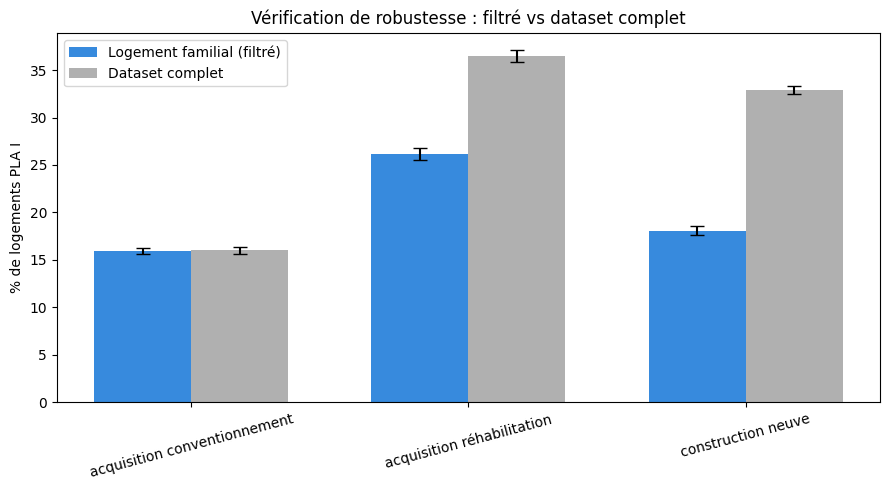

In [41]:
x = np.arange(len(modes))
width = 0.35

pct_filtre = [resultats[m]['pct'] for m in modes]
err_filtre = [[resultats[m]['pct'] - resultats[m]['low'] for m in modes],
              [resultats[m]['high'] - resultats[m]['pct'] for m in modes]]

pct_complet = [resultats_complet[m]['pct'] for m in modes]
err_complet = [[resultats_complet[m]['pct'] - resultats_complet[m]['low'] for m in modes],
               [resultats_complet[m]['high'] - resultats_complet[m]['pct'] for m in modes]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, pct_filtre, width, yerr=err_filtre, capsize=5,
       label='Logement familial (filtré)', color='#378ADD')
ax.bar(x + width/2, pct_complet, width, yerr=err_complet, capsize=5,
       label='Dataset complet', color='#B0B0B0')

ax.set_xticks(x)
ax.set_xticklabels(modes, rotation=15)
ax.set_ylabel("% de logements PLA I")
ax.set_title("Vérification de robustesse : filtré vs dataset complet")
ax.legend()
plt.tight_layout()
plt.savefig("../outputs/robustesse_filtre_vs_complet.png", dpi=150)
plt.show()


## 7. Robustesse — par arrondissement

On vérifie si la tendance observée se retrouve dans plusieurs arrondissements, ou si elle est concentrée dans un seul (ce qui affaiblirait la généralité du résultat).


In [42]:
par_arrdt = df_familial.groupby(['arrdt', 'mode_real'])[['nb_plai', 'nb_logmt_total']].sum()
par_arrdt['pct_plai'] = (par_arrdt['nb_plai'] / par_arrdt['nb_logmt_total'] * 100).round(1)

pivot_arrdt = par_arrdt['pct_plai'].unstack('mode_real')
print(pivot_arrdt)

comparable = pivot_arrdt.dropna()
n_confirme = (comparable['acquisition conventionnement'] == comparable.min(axis=1)).sum()
print(f"\nArrondissements où l'acquisition-conventionnement a le taux de PLA I le plus bas : "
      f"{n_confirme} / {len(comparable)}")


mode_real  acquisition conventionnement  acquisition réhabilitation  \
arrdt                                                                 
1                                   6.2                        35.8   
2                                  40.0                        34.1   
3                                  14.1                        39.7   
4                                   6.1                        29.6   
5                                  21.8                        23.0   
6                                  15.1                        28.9   
7                                  27.0                        37.3   
8                                  18.2                        45.1   
9                                  19.6                        36.1   
10                                 20.0                        32.4   
11                                 19.9                        27.2   
12                                 24.2                        32.8   
13    

### Visualisation  % PLA I par arrondissement × mode de réalisation


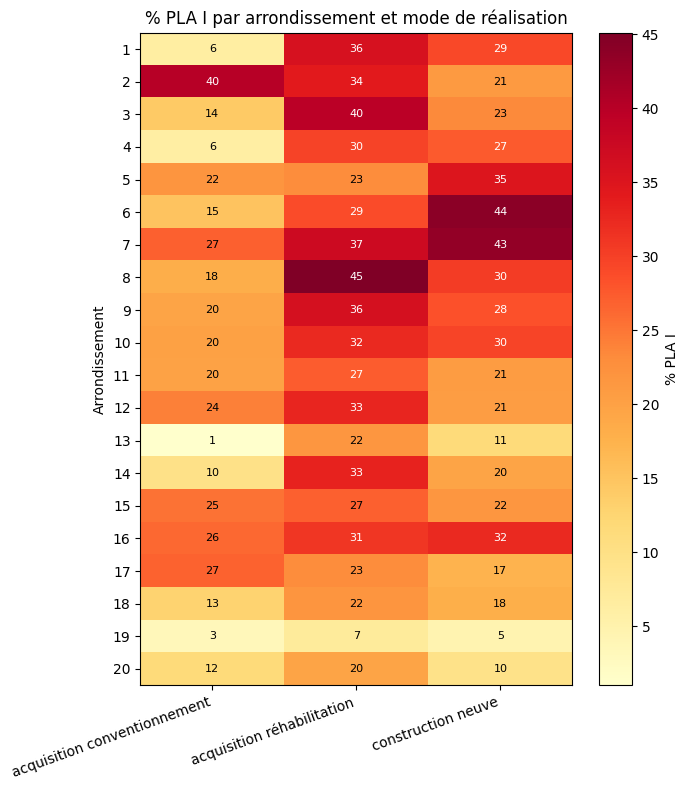

In [43]:
fig, ax = plt.subplots(figsize=(7, 8))
im = ax.imshow(pivot_arrdt.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(range(len(pivot_arrdt.columns)))
ax.set_xticklabels(pivot_arrdt.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot_arrdt.index)))
ax.set_yticklabels(pivot_arrdt.index)
ax.set_ylabel("Arrondissement")
ax.set_title("% PLA I par arrondissement et mode de réalisation")

vmax = pivot_arrdt.values[~pd.isna(pivot_arrdt.values)].max()
for i in range(len(pivot_arrdt.index)):
    for j in range(len(pivot_arrdt.columns)):
        val = pivot_arrdt.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f"{val:.0f}", ha='center', va='center',
                    fontsize=8, color='black' if val < vmax * 0.6 else 'white')

fig.colorbar(im, ax=ax, label="% PLA I")
plt.tight_layout()
plt.savefig("../outputs/heatmap_plai_par_arrdt.png", dpi=150)
plt.show()


## 8. Robustesse — par période

On découpe les données en trois périodes pour vérifier si la tendance est stable dans le temps.


In [44]:
bins = [2000, 2008, 2016, 2024]
periode_labels = ['2001-2008', '2009-2016', '2017-2024']
df_familial['periode'] = pd.cut(df_familial['annee'], bins=bins, labels=periode_labels, include_lowest=True)

par_periode = df_familial.groupby(['periode', 'mode_real'], observed=True)[['nb_plai', 'nb_logmt_total']].sum()
par_periode['pct_plai'] = (par_periode['nb_plai'] / par_periode['nb_logmt_total'] * 100).round(1)

pivot_periode = par_periode['pct_plai'].unstack('mode_real')
print(pivot_periode)


mode_real  acquisition conventionnement  acquisition réhabilitation  \
periode                                                               
2001-2008                           7.6                        22.3   
2009-2016                          14.8                        19.9   
2017-2024                          23.9                        35.1   

mode_real  construction neuve  
periode                        
2001-2008                 9.5  
2009-2016                19.3  
2017-2024                27.4  


### Visualisation — évolution du % PLA I dans le temps


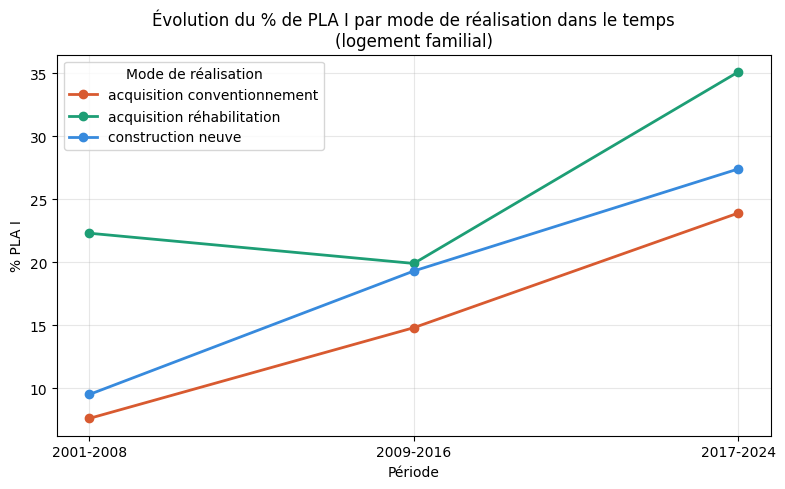

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
colors_map = {'acquisition conventionnement': '#D85A30',
              'construction neuve': '#378ADD',
              'acquisition réhabilitation': '#1D9E75'}

for mode in pivot_periode.columns:
    ax.plot(pivot_periode.index.astype(str), pivot_periode[mode], marker='o',
            label=mode, color=colors_map.get(mode), linewidth=2)

ax.set_ylabel("% PLA I")
ax.set_xlabel("Période")
ax.set_title("Évolution du % de PLA I par mode de réalisation dans le temps\n(logement familial)")
ax.legend(title="Mode de réalisation")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/evolution_plai_par_periode.png", dpi=150)
plt.show()


## Synthèse

**Résultats principaux (logement familial, n = 89 275 logements)**

| Mode de réalisation | % de PLA I | Intervalle (95% de certitude) |
|---|---|---|
| Acquisition-conventionnement | 15.9% | 15.6% – 16.3% |
| Construction neuve | 18.1% | 17.6% – 18.6% |
| Acquisition-réhabilitation | 26.1% | 25.5% – 26.8% |

- L'acquisition-conventionnement produit bien la part de logements très sociaux (PLA I) la plus faible des trois modes.
- Écart observé : environ **1.4 fois moins** de PLA I en acquisition-conventionnement que la moyenne des deux autres modes.
- Les intervalles de confiance ne se chevauchent pas entre l'acquisition-conventionnement et l'acquisition-réhabilitation : la différence n'est pas due au hasard.

**Robustesse dataset complet (sans filtre nature_programme)**
- Même tendance, mais écart plus marqué (16.0% vs 32.9% et 36.5%, soit environ 2.2x).
- Cet écart plus fort s'explique en partie par les résidences spécialisées (étudiantes, EHPAD, foyers) qui suivent une logique de financement différente et sont surreprésentées dans l'acquisition-réhabilitation et conventionnement. Le chiffre de 1.4x (logement familial) est plus fiable pour caractériser le logement social "classique".

**Robustesse par arrondissement**
- L'acquisition-conventionnement a le taux de PLA I le plus bas dans 15 arrondissements sur 20.
- La tendance est majoritaire mais pas universelle : 5 arrondissements font exception.

**Robustesse par période**
- La tendance est stable sur les trois périodes (2001-2008, 2009-2016, 2017-2024) : l'acquisition-conventionnement reste systématiquement en dessous des deux autres modes.
- L'écart entre modes tend à se réduire avec le temps, la part de PLA I augmentant globalement dans les trois modes.

**Conclusion**

Les logements sociaux issus d'un rachat de bâti existant (acquisition-conventionnement) contiennent une part de logements très sociaux (PLA I) significativement plus faible que ceux issus d'une construction neuve ou d'une réhabilitation — environ 16% contre 18-26%. Cet écart est confirmé statistiquement, stable dans le temps et présent dans la majorité des arrondissements parisiens.

**Limites**

- L'analyse porte sur des comptages agrégés de logements et non sur des programmes pondérés également : un grand programme pèse plus qu'un petit dans le calcul du pourcentage.
- Corrélation, pas causalité : le mode de réalisation est associé au type de financement, mais d'autres facteurs (contexte foncier, politique locale, contraintes du bâti existant) peuvent expliquer une partie de cet écart.
- L'ampleur exacte de l'écart varie selon le périmètre choisi (1.4x sur le logement familial, 2.2x sur le dataset complet) — ce point est documenté plutôt que masqué.
